In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/diabetes/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print(X.shape)

print(y.shape)

(768, 8)
(768,)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [7]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [8]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7532467532467533
Precision: 0.6491228070175439
Recall : 0.6727272727272727
F1 Score : 0.6607142857142857


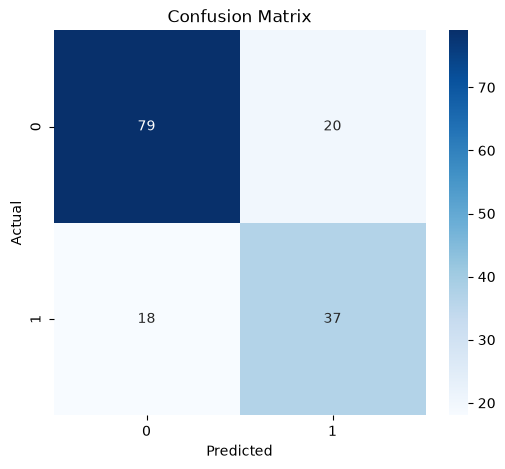

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [10]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [11]:
print("Random Forest Results")
print("----------------------")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest Results
----------------------
Accuracy : 0.7272727272727273
Precision: 0.6181818181818182
Recall : 0.6181818181818182
F1 Score : 0.6181818181818182


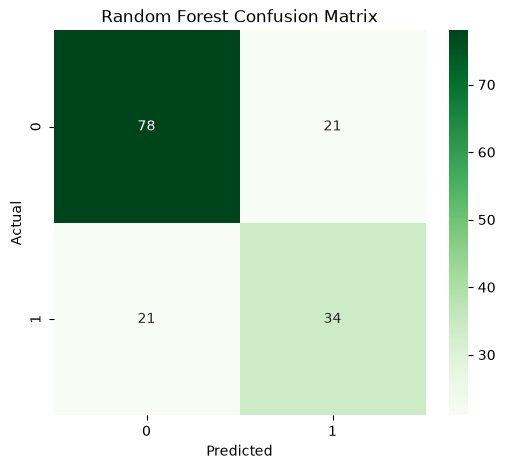

In [12]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)
print("Reduced Shape :", X_pca.shape)

Original Shape : (768, 8)
Reduced Shape : (768, 2)


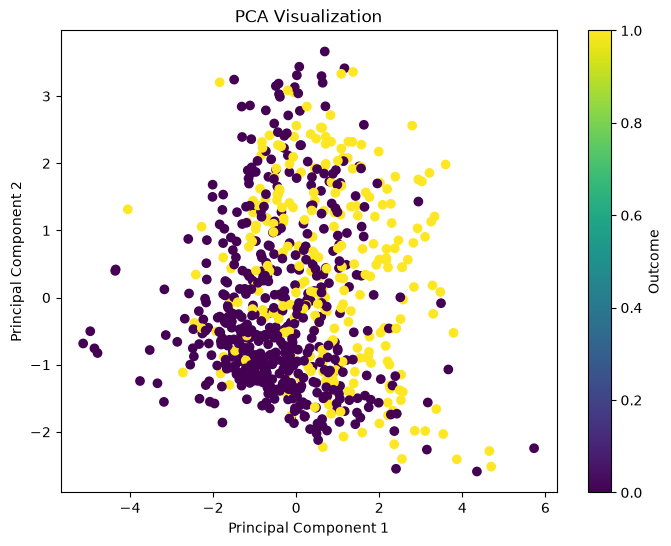

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.colorbar(label="Outcome")

plt.show()

In [15]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[accuracy_score(y_test,y_pred),
                accuracy_score(y_test,rf_pred)],
    "F1 Score":[f1_score(y_test,y_pred),
                f1_score(y_test,rf_pred)]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.753247,0.660714
1,Random Forest,0.727273,0.618182


In [16]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Logistic Regression model
joblib.dump(log_model, "../models/logistic_model.pkl")

# Save Random Forest model
joblib.dump(rf_model, "../models/random_forest.pkl")

print("Models Saved Successfully!")

Models Saved Successfully!
